# 🎯 Risk Alert Classifier

### 📁 Read the dataset 

In [44]:
import pandas as pd

df = pd.read_csv("Risk_Alert_Classifier_Dataset_4600 - Risk_Alert_Classifier_Dataset_4600.csv.csv")
df.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


In [45]:
df.tail()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
4595,504596,40.0,Male,North,NaN,39337.0,645.0,0.101,0,8.8,49,12591.0,0,0,0,23,2025-09-14,28947,0
4596,504597,35.0,Female,Central,Unemployed,34465.0,622.0,0.325,0,7.3,45,20146.0,3,0,4,18,2025-11-25,32475,0
4597,504598,31.0,Female,East,Self-Employed,NaN,693.0,0.583,1,7.1,36,16338.0,1,1,1,89,2025-09-16,52776,0
4598,504599,43.0,Male,East,Salaried,15000.0,540.0,0.915,4,16.0,60,13870.0,1,1,3,19,2025-09-07,20615,1
4599,504600,43.0,Female,South,Salaried,25325.0,657.0,0.184,0,3.1,85,12022.0,0,0,3,75,2025-11-01,18415,0


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   object 
 3   region                     4498 non-null   object 
 4   employment_type            4456 non-null   object 
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last_6m         4600 non-null   int64

In [47]:
df.describe()

,customer_id,age,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,debt_balance_inr,risk_status
count,4600.000000,4460.000000,4434.000000,4384.000000,4453.000000,4600.000000,4600.000000,4600.000000,4471.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,502300.500000,36.360314,41753.518268,677.784443,0.394721,0.924130,5.538696,65.030000,21511.273541,0.709783,0.443478,2.087174,53.744565,41143.328696,0.121087
std,1328.049949,10.670375,17740.750972,64.888787,0.205771,1.300018,5.624891,24.180762,10887.272864,1.020507,0.716546,1.621504,31.325334,26665.221097,0.326264
min,500001.000000,18.000000,15000.000000,405.000000,0.002000,0.000000,0.100000,5.000000,3769.000000,0.000000,0.000000,0.000000,2.000000,3653.000000,0.000000
25%,501150.750000,28.000000,28980.000000,638.000000,0.232000,0.000000,2.100000,49.000000,13422.500000,0.000000,0.000000,1.000000,31.000000,21302.750000,0.000000
50%,502300.500000,36.000000,38932.500000,682.000000,0.370000,1.000000,3.900000,65.000000,19317.000000,0.000000,0.000000,2.000000,48.000000,35638.500000,0.000000
75%,503450.250000,44.000000,51282.500000,721.250000,0.531000,1.000000,6.600000,81.000000,27147.000000,1.000000,1.000000,3.000000,70.000000,54274.250000,0.000000
max,504600.000000,75.000000,163002.000000,850.000000,0.978000,10.000000,47.100000,153.000000,87389.000000,7.000000,7.000000,12.000000,180.000000,213601.000000,1.000000


In [48]:
df.shape

(4600, 19)

In [49]:
df.columns

Index(['customer_id', 'age', 'gender', 'region', 'employment_type',
       'annual_income_inr', 'credit_score', 'credit_utilization_ratio',
       'missed_payments_12m', 'avg_late_payment_days',
       'monthly_transaction_count', 'monthly_spend_inr',
       'cash_advance_count_6m', 'complaints_last_6m',
       'failed_login_attempts_3m', 'account_tenure_months',
       'last_transaction_date', 'debt_balance_inr', 'risk_status'],
      dtype='object')

## 🧪 Part B — Dataset Understanding & Preparation

### Q7.  Identify input features and target variable.

In [50]:
X = df.drop("risk_status", axis=1)
y = df["risk_status"]

print("Input Features:")
print(X.columns)

print("\nTarget Variable:")
print(y.name)

Input Features:
Index(['customer_id', 'age', 'gender', 'region', 'employment_type',
       'annual_income_inr', 'credit_score', 'credit_utilization_ratio',
       'missed_payments_12m', 'avg_late_payment_days',
       'monthly_transaction_count', 'monthly_spend_inr',
       'cash_advance_count_6m', 'complaints_last_6m',
       'failed_login_attempts_3m', 'account_tenure_months',
       'last_transaction_date', 'debt_balance_inr'],
      dtype='object')

Target Variable:
risk_status


#### 💡 Insight 
- The code treats every column except `risk_status` as an input, which gives **18 features** and one target.
- `customer_id` is in that list. It is only an identifier and carries no risk information, so it should be dropped.
- `last_transaction_date` is a date stored as text, and `gender`, `region` and `employment_type` are categorical. None of these are encoded later in the notebook (see Q10).

### Q8. Perform a train-test split while maintaining class distribution.

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Class Distribution:")
print(y_test.value_counts(normalize=True))

Training Data: (3680, 18)
Testing Data: (920, 18)

Training Class Distribution:
risk_status
0    0.878804
1    0.121196
Name: proportion, dtype: float64

Testing Class Distribution:
risk_status
0    0.879348
1    0.120652
Name: proportion, dtype: float64


#### 💡 Insight 
- Training set: **3,680 rows**; test set: **920 rows** (80/20 split).
- `stratify=y` kept the class ratio almost identical: risky is **12.12%** in training and **12.07%** in testing.
- The test set therefore holds about 111 risky customers (confirmed by the confusion matrix in Q11), so metrics on the minority class rest on a small number of cases.

### Q9. Identify missing values and apply KNN Imputer for multivariate imputation.

In [52]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
customer_id                    0
age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64


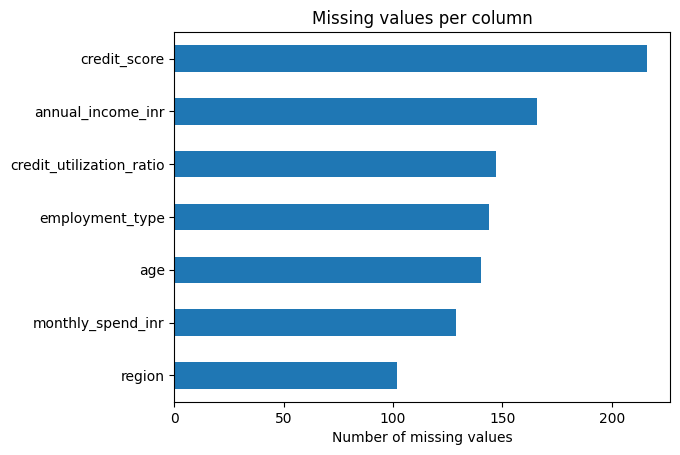

In [ ]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values()

missing.plot(kind="barh")
plt.xlabel("Number of missing values")
plt.title("Missing values per column")
plt.show()

In [54]:
from sklearn.impute import KNNImputer

numeric_columns = X_train.select_dtypes(include="number").columns

imputer = KNNImputer(n_neighbors=5)

X_train[numeric_columns] = imputer.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = imputer.transform(X_test[numeric_columns])

print("Missing values after KNN Imputation:")
print(X_train[numeric_columns].isnull().sum())

Missing values after KNN Imputation:
customer_id                  0
age                          0
annual_income_inr            0
credit_score                 0
credit_utilization_ratio     0
missed_payments_12m          0
avg_late_payment_days        0
monthly_transaction_count    0
monthly_spend_inr            0
cash_advance_count_6m        0
complaints_last_6m           0
failed_login_attempts_3m     0
account_tenure_months        0
debt_balance_inr             0
dtype: int64


#### 💡 Insight 
- Missing values appear in 7 columns: `credit_score` (216), `annual_income_inr` (166), `credit_utilization_ratio` (147), `employment_type` (144), `age` (140), `monthly_spend_inr` (129) and `region` (102). Out of 4,600 rows, none exceeds 5%.
- The imputer is **fitted on the training set only** and then applied to the test set, so no test information leaks into training.
- After imputation, the numeric columns show **0 missing values**.
- `KNNImputer` only works on numeric columns, so the missing values in `employment_type` and `region` are **not** filled by this step.

## 📊 Part C: Baseline Classification Model

### Q10. Implement Logistic Regression as a baseline model.


In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled = scaler.transform(X_test[numeric_columns])

model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

#### 💡 Insight 
- The scaler is fitted on the training set only, which is the correct way to avoid leakage. Scaling matters here because Logistic Regression is sensitive to feature scale.
- The model uses only `numeric_columns`, so `gender`, `region`, `employment_type` and `last_transaction_date` are **not used**.
- `customer_id` is in `numeric_columns`, so it was imputed, scaled and fed to the model as if it were a real feature.

### Q11. Generate and interpret:
* Confusion Matrix
* Accuracy Score
* Precision , Recall , F1-Score

In [56]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[809   0]
 [  0 111]]

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0


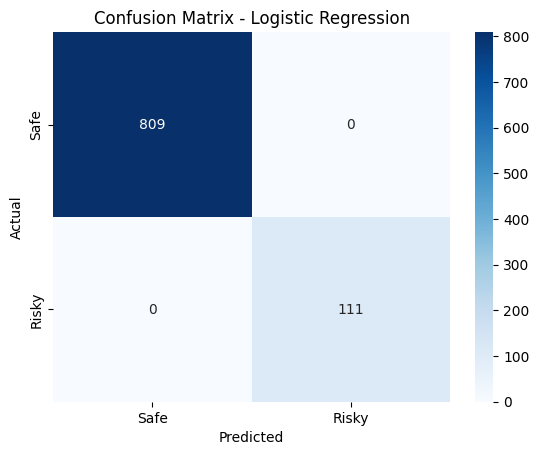

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",xticklabels=["Safe", "Risky"], yticklabels=["Safe", "Risky"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

#### 💡 Insight 
- Confusion matrix `[[809, 0], [0, 111]]`: all 809 safe and all 111 risky customers were classified correctly.
- Accuracy, precision, recall and F1 are all **1.0**.
- A perfect score on 920 rows is unusual. It suggests the numeric features separate the two classes almost linearly, but it also means this single split cannot tell us how the model behaves on harder cases.
- Precision of 1.0 means every alert was a real risk. Recall of 1.0 means no risky customer was missed.

### Q12. Identify Type-I and Type-II errors from the confusion matrix.

In [58]:
TN, FP, FN, TP = cm.ravel()

print("Type-I Error (False Positive):", FP)
print("Type-II Error (False Negative):", FN)

Type-I Error (False Positive): 0
Type-II Error (False Negative): 0


#### 💡 Insight 
- **Type-I error (false positive) = 0**: no safe customer was wrongly flagged as risky, so no unnecessary alerts.
- **Type-II error (false negative) = 0**: no risky customer was missed. In credit risk this is the costlier error, so this is the best possible result on this test set.

## ⚖️ Part D: Handling Imbalanced Data

### Q13. Demonstrate the impact of class imbalance on model performance.

In [59]:
print("Class Distribution:")
print(y.value_counts())

print("\nClass Distribution Percentage:")
print(y.value_counts(normalize=True) * 100)

Class Distribution:
risk_status
0    4043
1     557
Name: count, dtype: int64

Class Distribution Percentage:
risk_status
0    87.891304
1    12.108696
Name: proportion, dtype: float64


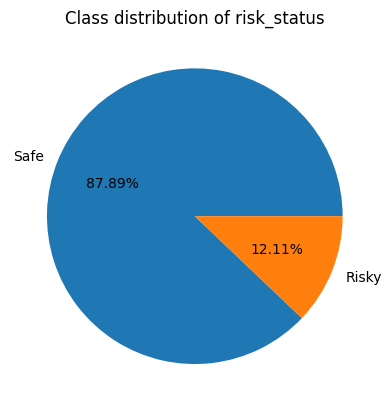

In [ ]:
import matplotlib.pyplot as plt

counts = y.value_counts().sort_index()

plt.pie(counts, labels=["Safe", "Risky"], autopct="%1.2f%%")
plt.title("Class distribution of risk_status")
plt.show()

In [61]:
print("Baseline Model Performance:")
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

Baseline Model Performance:
Recall: 1.0
F1-Score: 1.0


#### 💡 Insight 
- The class distribution is **4,043 safe (87.89%)** against **557 risky (12.11%)**, which is about 7 safe customers for every risky one.
- A model that always predicted "safe" would reach roughly 88% accuracy while catching no risky customers, so accuracy alone is not a reliable measure here.
- In this notebook the imbalance did **not** hurt the baseline: recall and F1 are both 1.0, so there was no minority-class weakness to demonstrate.

### Q14. Apply the following techniques and retrain the model:

### Under-Sampling

In [62]:
from imblearn.under_sampling import RandomUnderSampler

under = RandomUnderSampler(random_state=42)
X_under, y_under = under.fit_resample(X_train_scaled, y_train)
model_under = LogisticRegression(random_state=42)
model_under.fit(X_under, y_under)
y_pred_under = model_under.predict(X_test_scaled)

### Over-Sampling

In [63]:
from imblearn.over_sampling import RandomOverSampler

over = RandomOverSampler(random_state=42)
X_over, y_over = over.fit_resample(X_train_scaled, y_train)
model_over = LogisticRegression(random_state=42)
model_over.fit(X_over, y_over)
y_pred_over = model_over.predict(X_test_scaled)

### SMOTE

In [64]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)
model_smote = LogisticRegression(random_state=42)
model_smote.fit(X_smote, y_smote)
y_pred_smote = model_smote.predict(X_test_scaled)

### ADASYN

In [65]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
model_adasyn = LogisticRegression(random_state=42)
model_adasyn.fit(X_adasyn, y_adasyn)
y_pred_adasyn = model_adasyn.predict(X_test_scaled)

#### 💡 Insight 
- All four techniques are applied **only to the scaled training data**. The test set is untouched, so the results in Q15 are fair.
- Under-sampling shrinks the safe class down to the risky class size, which throws away safe-customer data. Over-sampling duplicates risky rows. SMOTE and ADASYN create new synthetic risky rows instead.

### Q15. Compare performance before and after balancing using:

* Recall for minority class
* AUC-ROC
* F1-Score

In [66]:
from sklearn.metrics import roc_auc_score

results = pd.DataFrame({
    "Model": [
        "Before Balancing",
        "Under-Sampling",
        "Over-Sampling",
        "SMOTE",
        "ADASYN"
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_under),
        recall_score(y_test, y_pred_over),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_adasyn)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_under),
        f1_score(y_test, y_pred_over),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_adasyn)
    ],
    "AUC-ROC": [
        roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, model_under.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, model_over.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, model_smote.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, model_adasyn.predict_proba(X_test_scaled)[:, 1])
]
})

print(results)

              Model  Recall  F1-Score   AUC-ROC
0  Before Balancing     1.0  1.000000  1.000000
1    Under-Sampling     1.0  0.982301  1.000000
2     Over-Sampling     1.0  0.986667  1.000000
3             SMOTE     1.0  0.991071  1.000000
4            ADASYN     1.0  0.969432  0.999978


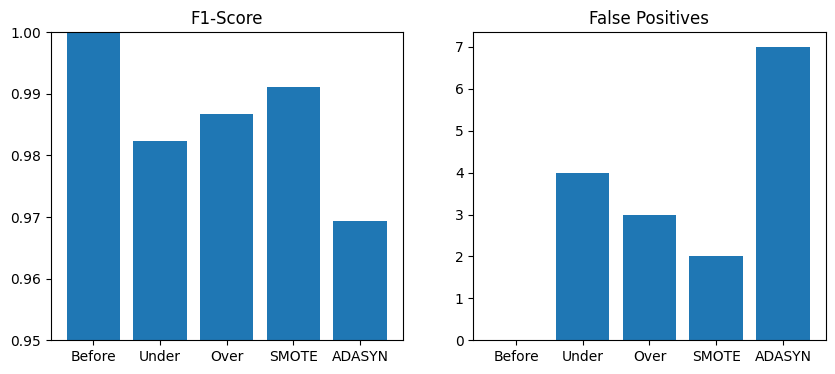

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

names = ["Before", "Under", "Over", "SMOTE", "ADASYN"]
all_preds = [y_pred, y_pred_under, y_pred_over, y_pred_smote, y_pred_adasyn]
false_positives = [confusion_matrix(y_test, p)[0][1] for p in all_preds]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(names, results["F1-Score"])
plt.ylim(0.95, 1.0)
plt.title("F1-Score")

plt.subplot(1, 2, 2)
plt.bar(names, false_positives)
plt.title("False Positives")

plt.show()

#### 💡 Insight 
- **Recall is 1.0 for every method**, and AUC-ROC is 1.0 for all except ADASYN (0.999978).
- **F1 dropped after balancing**: Under-Sampling 0.9823, Over-Sampling 0.9867, SMOTE 0.9911, ADASYN 0.9694.
- Since recall stayed at 1.0, the F1 drop must come from lower precision. From the F1 values this implies roughly **4 false positives for under-sampling, 3 for over-sampling, 2 for SMOTE and 7 for ADASYN** (calculated from the F1 scores above, with 111 risky customers in the test set).
- **SMOTE** performed best of the four and **ADASYN** worst.
- **Conclusion:** balancing did not improve anything because the baseline was already perfect. It only added a few false alarms.

## 🌲 Part E: Tree-Based Classification Models

### Q16. Implement Decision Tree Classifier.

In [68]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_scaled, y_train)

dt_train_pred = dt_model.predict(X_train_scaled)
dt_test_pred = dt_model.predict(X_test_scaled)

print("Decision Tree Accuracy:")
print("Training:", accuracy_score(y_train, dt_train_pred))
print("Testing:", accuracy_score(y_test, dt_test_pred))

Decision Tree Accuracy:
Training: 1.0
Testing: 0.9706521739130435


#### 💡 Insight 
- The Decision Tree reaches **100% training accuracy** and **97.07% test accuracy**.
- Perfect training accuracy from an unrestricted tree (no `max_depth` set) means it has memorized the training data.
- A 97.07% test accuracy implies about 27 wrong predictions out of 920, whereas Logistic Regression made 0.

### Q17. Analyze overfitting by comparing training and testing performance.

In [69]:
print("Training Accuracy:", accuracy_score(y_train, dt_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, dt_test_pred))

Training Accuracy: 1.0
Testing Accuracy: 0.9706521739130435


#### 💡 Insight 
- The gap between training (**1.0**) and testing (**0.9707**) is about **2.9 percentage points**. This is overfitting.
- The tree fits the training data perfectly but does not carry that performance over to unseen customers.

### Q18. Implement Random Forest Classifier.

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42,n_estimators=100)

rf_model.fit(X_train_scaled, y_train)

rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy:")
print("Training:", accuracy_score(y_train, rf_train_pred))
print("Testing:", accuracy_score(y_test, rf_test_pred))

Random Forest Accuracy:
Training: 1.0
Testing: 0.9967391304347826


#### 💡 Insight 
- The Random Forest also reaches **100% training accuracy**, but its test accuracy is **99.67%**, which means only about 3 mistakes in 920 rows.
- The train–test gap is just **0.33 points**, compared with about 2.9 for the single tree.

### Q19. Compare Decision Tree vs Random Forest in terms of accuracy and generalization.

In [71]:
print("Decision Tree Test Accuracy:",accuracy_score(y_test, dt_test_pred))
print("Random Forest Test Accuracy:",accuracy_score(y_test, rf_test_pred))

Decision Tree Test Accuracy: 0.9706521739130435
Random Forest Test Accuracy: 0.9967391304347826


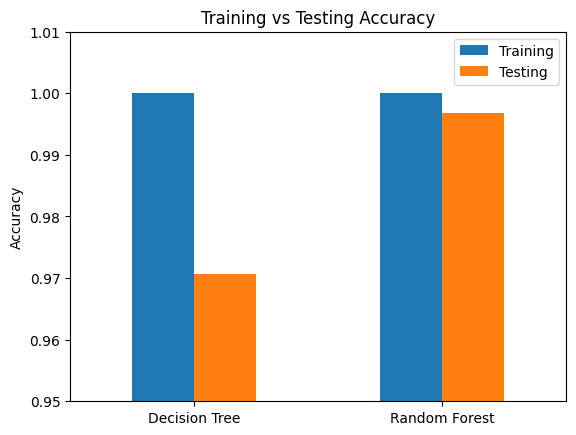

In [ ]:
import matplotlib.pyplot as plt

acc = pd.DataFrame({
    "Training": [accuracy_score(y_train, dt_train_pred), accuracy_score(y_train, rf_train_pred)],
    "Testing":  [accuracy_score(y_test, dt_test_pred),  accuracy_score(y_test, rf_test_pred)]
}, index=["Decision Tree", "Random Forest"])

acc.plot(kind="bar", ylim=(0.95, 1.01), rot=0)
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")
plt.show()

#### 💡 Insight 
- Random Forest is better on test accuracy: **99.67% vs 97.07%**, so the error rate falls from about 2.9% to about 0.33%.
- A Random Forest averages 100 trees trained on different samples of the data, which reduces the variance that makes a single tree overfit.
- Random Forest generalizes clearly better than the Decision Tree.

## 🔧 Part F: Hyperparameter Tuning

### Q20. Apply Randomized Search CV to optimize

### Decision Tree hyperparameters 

In [73]:
from sklearn.model_selection import RandomizedSearchCV

dt_params = {"max_depth": [3, 5, 7, 10, None],"min_samples_split": [2, 5, 10],"min_samples_leaf": [1, 2, 4]}

dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=dt_params,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=42)

dt_random.fit(X_train_scaled, y_train)

print("Best Decision Tree Parameters:")
print(dt_random.best_params_)

Best Decision Tree Parameters:
{'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}


### Random Forest hyperparameters

In [74]:
rf_params = {"n_estimators": [50, 100, 150],"max_depth": [5, 10, 15, None],"min_samples_split": [2, 5, 10],"min_samples_leaf": [1, 2, 4]}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=42
)

rf_random.fit(X_train_scaled, y_train)

print("Best Random Forest Parameters:")
print(rf_random.best_params_)

Best Random Forest Parameters:
{'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 15}


#### 💡 Insight 
- **Decision Tree** best parameters: `max_depth=None`, `min_samples_split=2`, `min_samples_leaf=2`. The search chose no depth limit and only changed `min_samples_leaf` from the default.
- **Random Forest** best parameters: `n_estimators=150`, `max_depth=15`, `min_samples_split=10`, `min_samples_leaf=1`.
- Both searches used `scoring="f1"` with 5-fold cross-validation, which suits an imbalanced target better than accuracy.
- Only 10 random combinations were tried (`n_iter=10`), so these are good settings but not necessarily the best possible.

### Q21. Apply Grid Search CV for fine-tuning the best performing model.

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_params = {"max_depth": [5, 10, 15],"min_samples_split": [2, 5],"min_samples_leaf": [1, 2]}

grid = GridSearchCV(RandomForestClassifier(n_estimators=100,random_state=42),param_grid=grid_params,cv=5,scoring="f1")

grid.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5}


#### 💡 Insight 
- Grid Search best parameters: `max_depth=15`, `min_samples_split=5`, `min_samples_leaf=1`.
- It agrees with the randomized search on `max_depth=15` and `min_samples_leaf=1`, so those two settings look stable.
- The grid fixed `n_estimators=100`, so it fine-tunes tree depth and split rules only.

### Q22. Compare tuned vs untuned model performance.

In [76]:
tuned_model = grid.best_estimator_

tuned_pred = tuned_model.predict(X_test_scaled)

print("Untuned Random Forest Accuracy:",accuracy_score(y_test, rf_test_pred))
print("Tuned Random Forest Accuracy:",accuracy_score(y_test, tuned_pred))
print("\nUntuned F1-Score:",f1_score(y_test, rf_test_pred))
print("Tuned F1-Score:",f1_score(y_test, tuned_pred))

Untuned Random Forest Accuracy: 0.9967391304347826


Tuned Random Forest Accuracy: 0.9978260869565218

Untuned F1-Score: 0.9865470852017937
Tuned F1-Score: 0.990990990990991


#### 💡 Insight 
- Accuracy: **0.9967 → 0.9978**. F1: **0.9865 → 0.9910**.
- On 920 test rows that is about **3 errors down to 2**, so tuning fixed one prediction.
- The improvement is real but very small, because the untuned Random Forest was already close to perfect.

## 📈 Part G: Model Evaluation & ROC Analysis

### Q23. Plot and interpret the ROC Curve for all models.

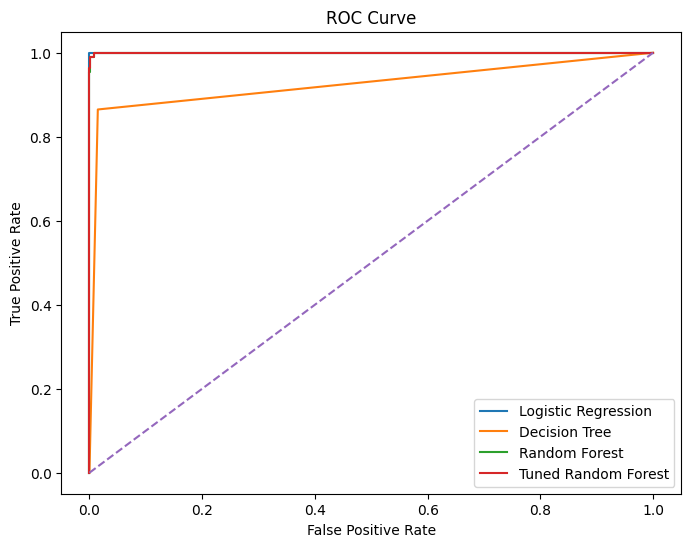

In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

models = {"Logistic Regression": model,"Decision Tree": dt_model,"Random Forest": rf_model,"Tuned Random Forest": tuned_model}

plt.figure(figsize=(8, 6))

for name, m in models.items():
    y_prob = m.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### 💡 Insight 
- Logistic Regression, Random Forest and Tuned Random Forest curves go straight up the left edge and across the top, which is the ideal ROC shape.
- The **Decision Tree** curve is clearly lower. It shows a single corner point at about 86% true positive rate with a small false positive rate, which is typical of a tree that gives only hard 0/1 predictions.
- The Random Forest and Tuned Random Forest curves overlap, which matches their identical AUC in Q24.
- All curves are far above the diagonal dashed line, which represents random guessing.

### Q24. Compute and compare AUC-ROC scores.

In [78]:
for name, m in models.items():
    y_prob = m.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    print(name, "AUC-ROC:", auc)

Logistic Regression AUC-ROC: 1.0
Decision Tree AUC-ROC: 0.9250158687735943
Random Forest AUC-ROC: 0.9998886401853027
Tuned Random Forest AUC-ROC: 0.9998886401853027


#### 💡 Insight 
- **Logistic Regression: 1.0**; **Random Forest and Tuned Random Forest: 0.99989** (identical); **Decision Tree: 0.925**.
- The Decision Tree has the lowest AUC by a clear margin, so it ranks customers by risk worst.
- Tuning left the Random Forest AUC unchanged, so its small improvement in Q22 shows up in the final predictions, not in how customers are ranked.

### Q25. Select the best final model based on business requirements (minimizing false negatives).

In [79]:
final_models = {"Logistic Regression": model,"Decision Tree": dt_model,"Random Forest": rf_model,"Tuned Random Forest": tuned_model}

best_model = None
best_recall = 0

for name, m in final_models.items():
    y_pred_model = m.predict(X_test_scaled)
    recall = recall_score(y_test, y_pred_model)

    print(name, "Recall:", recall)

    if recall > best_recall:
        best_recall = recall
        best_model = name

print("\nBest Final Model:", best_model)
print("Best Recall:", best_recall)

Logistic Regression Recall: 1.0
Decision Tree Recall: 0.8648648648648649
Random Forest Recall: 0.990990990990991
Tuned Random Forest Recall: 0.990990990990991

Best Final Model: Logistic Regression
Best Recall: 1.0


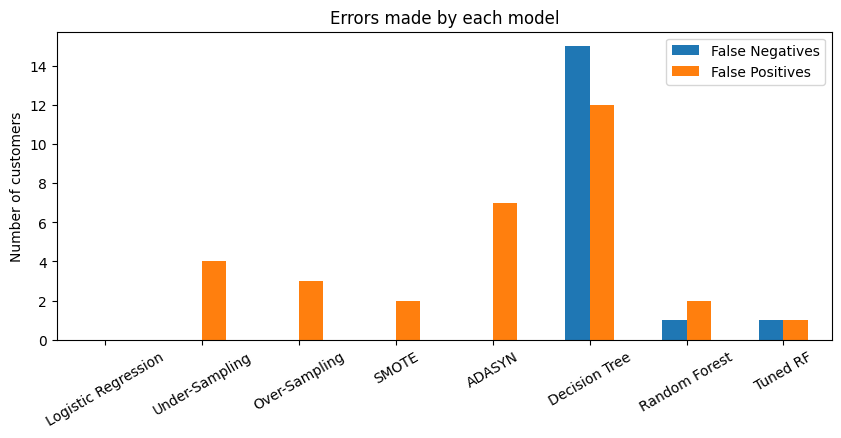

In [ ]:
import matplotlib.pyplot as plt

all_preds = {
    "Logistic Regression": y_pred, "Under-Sampling": y_pred_under,
    "Over-Sampling": y_pred_over, "SMOTE": y_pred_smote, "ADASYN": y_pred_adasyn,
    "Decision Tree": dt_test_pred, "Random Forest": rf_test_pred, "Tuned RF": tuned_pred
}

errors = pd.DataFrame({
    "False Negatives": [confusion_matrix(y_test, p)[1][0] for p in all_preds.values()],
    "False Positives": [confusion_matrix(y_test, p)[0][1] for p in all_preds.values()]
}, index=all_preds.keys())

errors.plot(kind="bar", figsize=(10, 4))
plt.ylabel("Number of customers")
plt.title("Errors made by each model")
plt.xticks(rotation=30)
plt.show()

#### 💡 Insight 
| Model | Recall | Risky customers missed (of 111) |
|---|---|---|
| Logistic Regression | 1.0000 | 0 |
| Random Forest | 0.9910 | 1 |
| Tuned Random Forest | 0.9910 | 1 |
| Decision Tree | 0.8649 | 15 |

- The code picks the model with the highest recall, which is **Logistic Regression**, matching the goal of minimizing false negatives.
- The Decision Tree is the worst choice: it would let about 15 risky customers through.
- The comparison uses `>`, so if two models had tied on recall, the first one listed would win.
- Caveat: the gap between 0 and 1 missed customers is based on only 111 risky cases in one test split. Cross-validation would confirm this before deployment.

## 🏁 Overall Conclusion
- The numeric features separate risky from safe customers almost perfectly: Logistic Regression scored 1.0 on every metric.
- Class imbalance (12.11% risky) did not hurt the baseline, so under-sampling, over-sampling, SMOTE and ADASYN did not help and slightly lowered F1.
- A single Decision Tree overfits (1.0 train vs 0.9707 test). Random Forest fixes most of that (0.9967), and tuning adds only a tiny gain (0.9978).
- **Logistic Regression is the final model**, since it has zero false negatives and is easy to explain.
- **Before deployment:** remove `customer_id`, decide how to use the unused categorical columns, and confirm results with cross-validation.